# Reinforcement Learning: Sim2Sim Transfer Data Visualization
Using a policy trained in IsaacLab, deploy to Mujoco on the same robot platform (AnyMAL C).

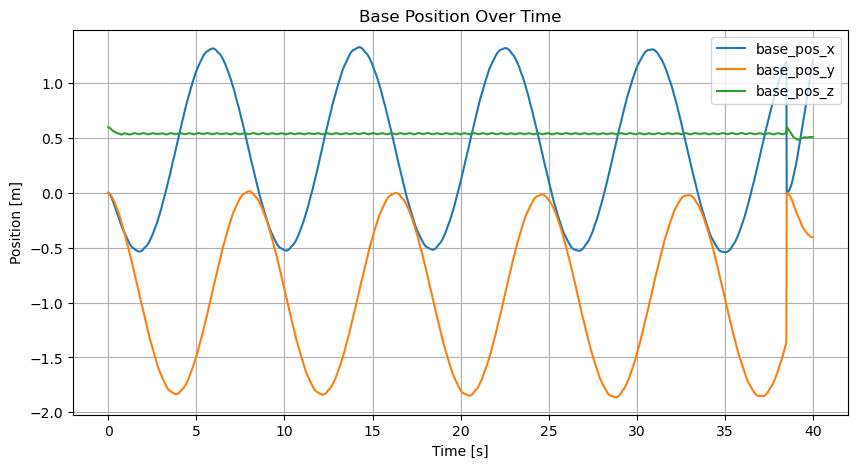

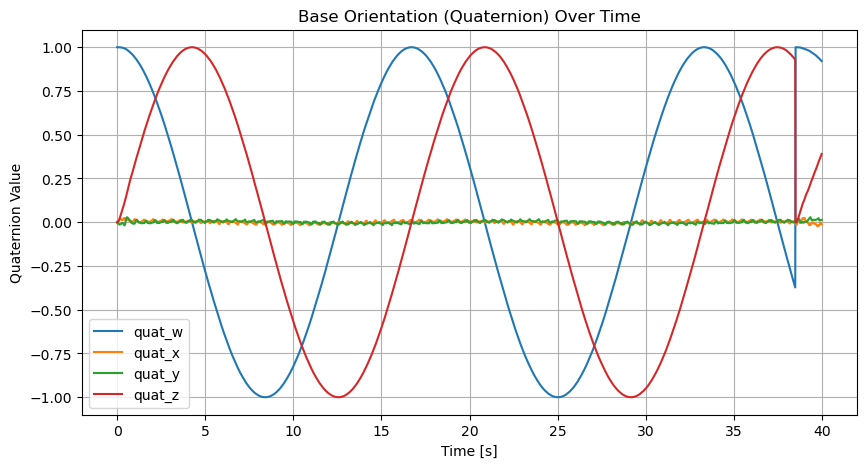

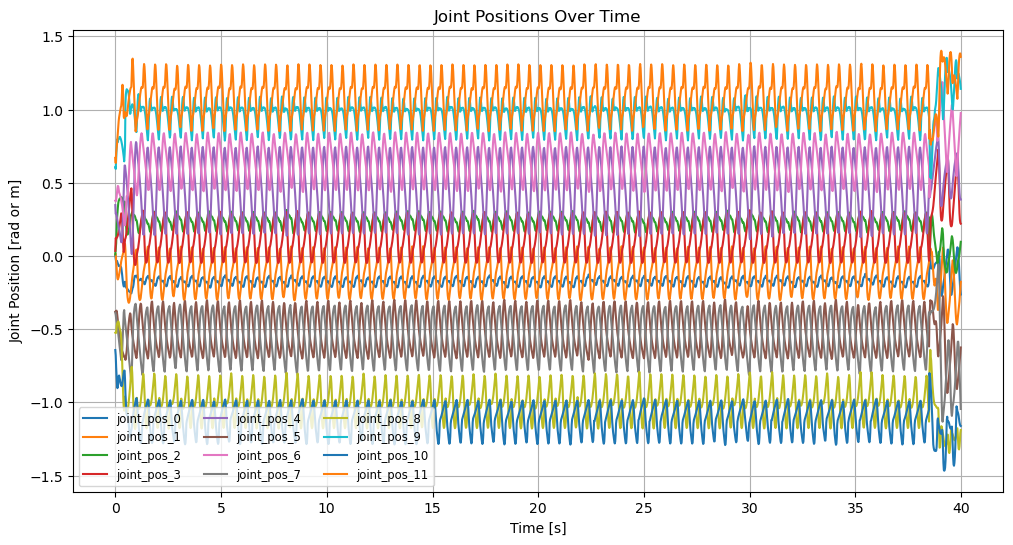

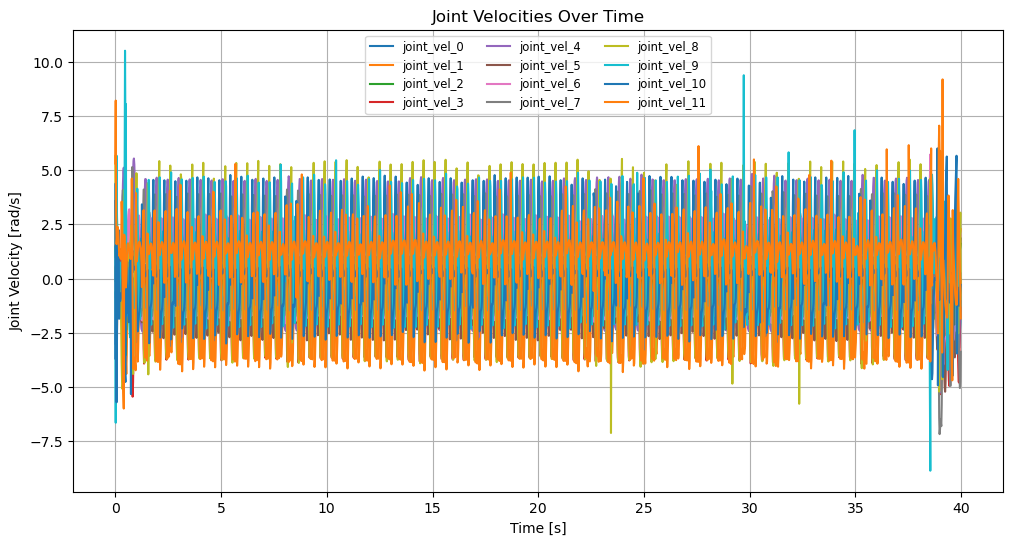

In [4]:
# IsaacLab Replay

import pandas as pd
import matplotlib.pyplot as plt

# ---- CONFIG ----
CSV_FILE = "isaaclab_single_robot.csv"  # Change to your actual file path
SHOW_FIG = True              # Set False if you just want to save the figures
SAVE_FIG = False              # Saves all plots as PNGs
# ----------------

# Read CSV
df = pd.read_csv(CSV_FILE)

# --- BASE POSITION ---
plt.figure(figsize=(10, 5))
plt.plot(df['time'], df['base_pos_x'], label='base_pos_x')
plt.plot(df['time'], df['base_pos_y'], label='base_pos_y')
plt.plot(df['time'], df['base_pos_z'], label='base_pos_z')
plt.title("Base Position Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.legend()
plt.grid(True)
if SAVE_FIG: plt.savefig("base_position.png", dpi=200, bbox_inches='tight')

# --- BASE ORIENTATION (QUATERNION) ---
plt.figure(figsize=(10, 5))
plt.plot(df['time'], df['base_quat_w'], label='quat_w')
plt.plot(df['time'], df['base_quat_x'], label='quat_x')
plt.plot(df['time'], df['base_quat_y'], label='quat_y')
plt.plot(df['time'], df['base_quat_z'], label='quat_z')
plt.title("Base Orientation (Quaternion) Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Quaternion Value")
plt.legend()
plt.grid(True)
if SAVE_FIG: plt.savefig("base_orientation.png", dpi=200, bbox_inches='tight')

# --- JOINT POSITIONS ---
joint_pos_cols = [col for col in df.columns if col.startswith('joint_pos_')]
plt.figure(figsize=(12, 6))
for col in joint_pos_cols:
    plt.plot(df['time'], df[col], label=col)
plt.title("Joint Positions Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Joint Position [rad or m]")
plt.legend(ncol=3, fontsize='small')
plt.grid(True)
if SAVE_FIG: plt.savefig("joint_positions.png", dpi=200, bbox_inches='tight')

# --- JOINT VELOCITIES ---
joint_vel_cols = [col for col in df.columns if col.startswith('joint_vel_')]
plt.figure(figsize=(12, 6))
for col in joint_vel_cols:
    plt.plot(df['time'], df[col], label=col)
plt.title("Joint Velocities Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Joint Velocity [rad/s]")
plt.legend(ncol=3, fontsize='small')
plt.grid(True)
if SAVE_FIG: plt.savefig("joint_velocities.png", dpi=200, bbox_inches='tight')

# --- CONTACT FORCES ---
contact_force_cols = [col for col in df.columns if col.startswith('contact_force_')]

# Group by limb (LF, RF, LH, RH)
limbs = sorted(set(col.split('_')[2] for col in contact_force_cols))  # ['LF', 'LH', 'RF', 'RH']

for limb in limbs:
    plt.figure(figsize=(10, 5))
    cols = [col for col in contact_force_cols if f'_{limb}_' in col]
    for col in cols:
        plt.plot(df['time'], df[col], label=col)
    plt.title(f"Contact Forces ({limb}) Over Time")
    plt.xlabel("Time [s]")
    plt.ylabel("Force [N]")
    plt.legend()
    plt.grid(True)
    if SAVE_FIG:
        plt.savefig(f"contact_forces_{limb}.png", dpi=200, bbox_inches='tight')


if SHOW_FIG:
    plt.show()


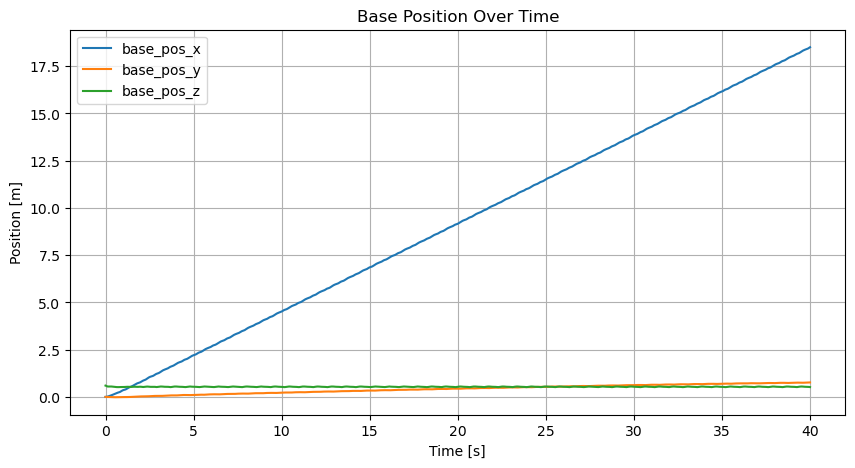

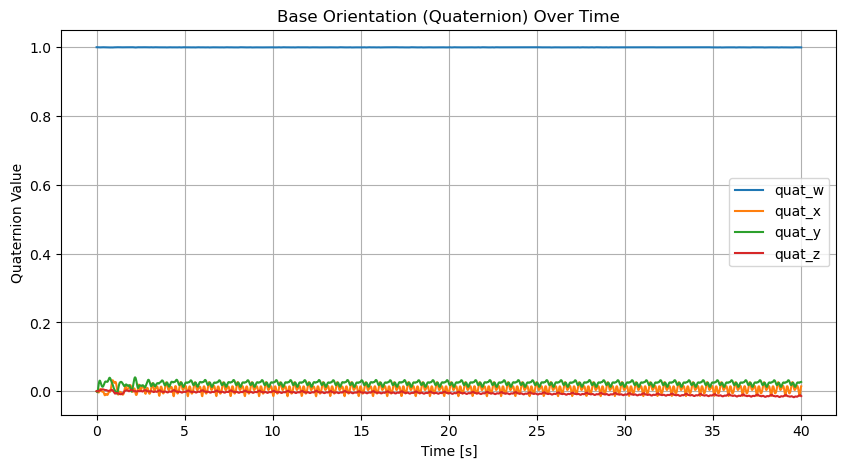

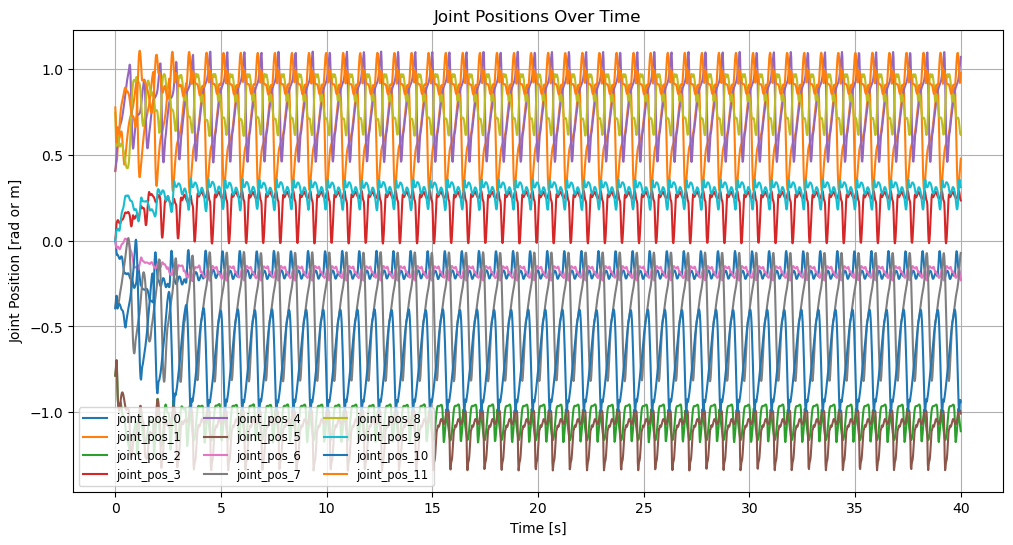

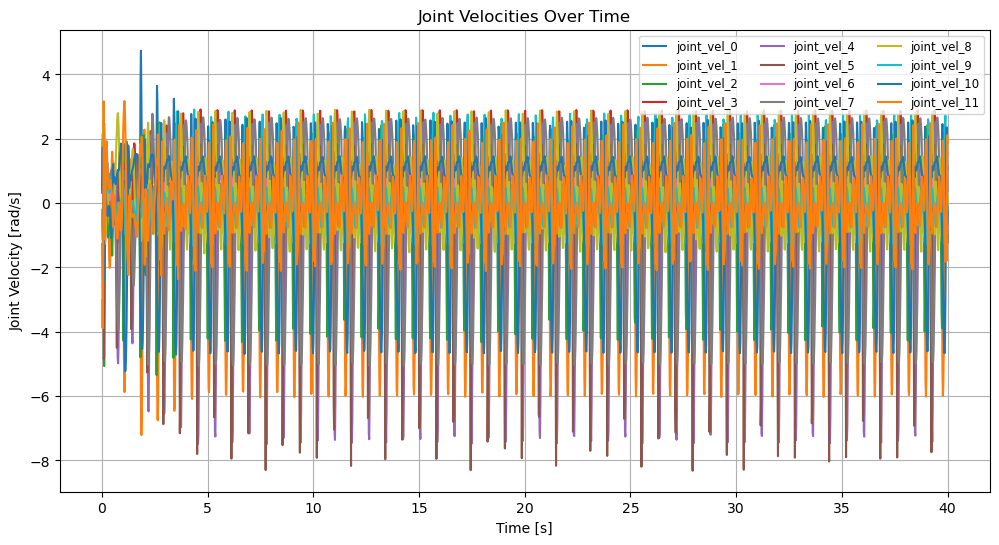

In [5]:
# Mujoco Replay

import pandas as pd
import matplotlib.pyplot as plt

# ---- CONFIG ----
CSV_FILE = "mujoco_single_robot_log.csv"  # Change to your actual file path
SHOW_FIG = True              # Set False if you just want to save the figures
SAVE_FIG = False              # Saves all plots as PNGs
# ----------------

# Read CSV
df = pd.read_csv(CSV_FILE)
df = df[df['time'].between(0, 40)]  # Filter to match IsaacLab replay data since we have more than 40 seconds of data

# --- BASE POSITION ---
plt.figure(figsize=(10, 5))
plt.plot(df['time'], df['base_pos_x'], label='base_pos_x')
plt.plot(df['time'], df['base_pos_y'], label='base_pos_y')
plt.plot(df['time'], df['base_pos_z'], label='base_pos_z')
plt.title("Base Position Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.legend()
plt.grid(True)
if SAVE_FIG: plt.savefig("base_position.png", dpi=200, bbox_inches='tight')

# --- BASE ORIENTATION (QUATERNION) ---
plt.figure(figsize=(10, 5))
plt.plot(df['time'], df['base_quat_w'], label='quat_w')
plt.plot(df['time'], df['base_quat_x'], label='quat_x')
plt.plot(df['time'], df['base_quat_y'], label='quat_y')
plt.plot(df['time'], df['base_quat_z'], label='quat_z')
plt.title("Base Orientation (Quaternion) Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Quaternion Value")
plt.legend()
plt.grid(True)
if SAVE_FIG: plt.savefig("base_orientation.png", dpi=200, bbox_inches='tight')

# --- JOINT POSITIONS ---
joint_pos_cols = [col for col in df.columns if col.startswith('joint_pos_')]
plt.figure(figsize=(12, 6))
for col in joint_pos_cols:
    plt.plot(df['time'], df[col], label=col)
plt.title("Joint Positions Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Joint Position [rad or m]")
plt.legend(ncol=3, fontsize='small')
plt.grid(True)
if SAVE_FIG: plt.savefig("joint_positions.png", dpi=200, bbox_inches='tight')

# --- JOINT VELOCITIES ---
joint_vel_cols = [col for col in df.columns if col.startswith('joint_vel_')]
plt.figure(figsize=(12, 6))
for col in joint_vel_cols:
    plt.plot(df['time'], df[col], label=col)
plt.title("Joint Velocities Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Joint Velocity [rad/s]")
plt.legend(ncol=3, fontsize='small')
plt.grid(True)
if SAVE_FIG: plt.savefig("joint_velocities.png", dpi=200, bbox_inches='tight')

# --- CONTACT FORCES ---
contact_force_cols = [col for col in df.columns if col.startswith('contact_force_')]

# Group by limb (LF, RF, LH, RH)
limbs = sorted(set(col.split('_')[2] for col in contact_force_cols))  # ['LF', 'LH', 'RF', 'RH']

for limb in limbs:
    plt.figure(figsize=(10, 5))
    cols = [col for col in contact_force_cols if f'_{limb}_' in col]
    for col in cols:
        plt.plot(df['time'], df[col], label=col)
    plt.title(f"Contact Forces ({limb}) Over Time")
    plt.xlabel("Time [s]")
    plt.ylabel("Force [N]")
    plt.legend()
    plt.grid(True)
    if SAVE_FIG:
        plt.savefig(f"contact_forces_{limb}.png", dpi=200, bbox_inches='tight')


if SHOW_FIG:
    plt.show()


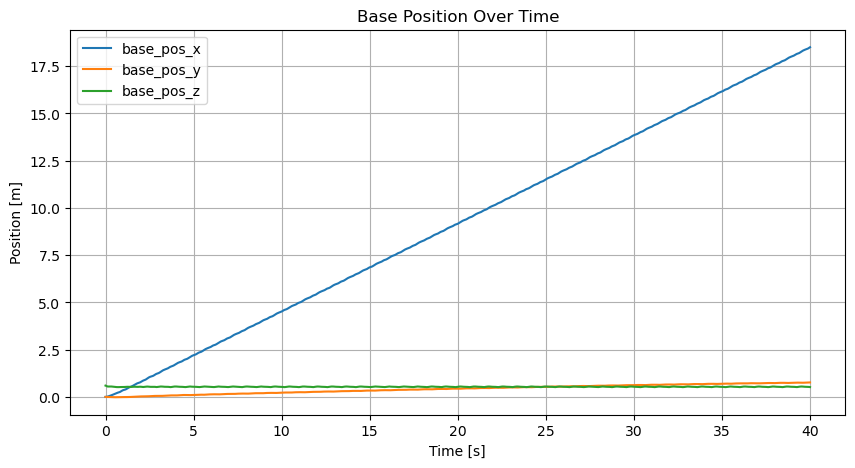

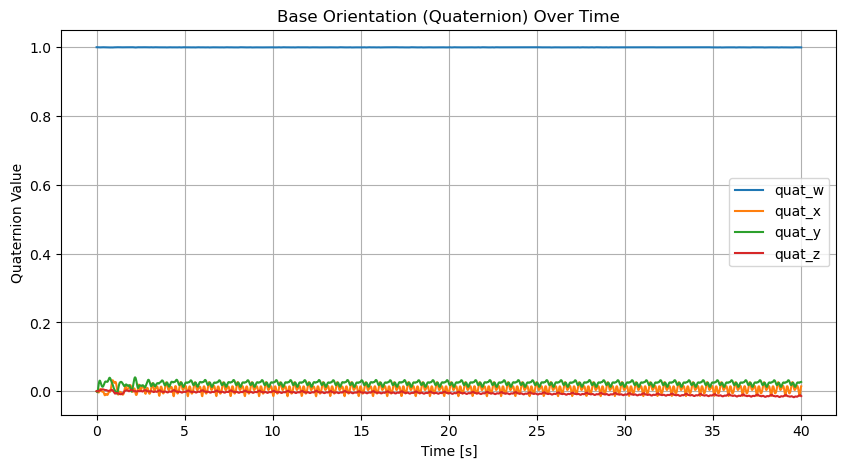

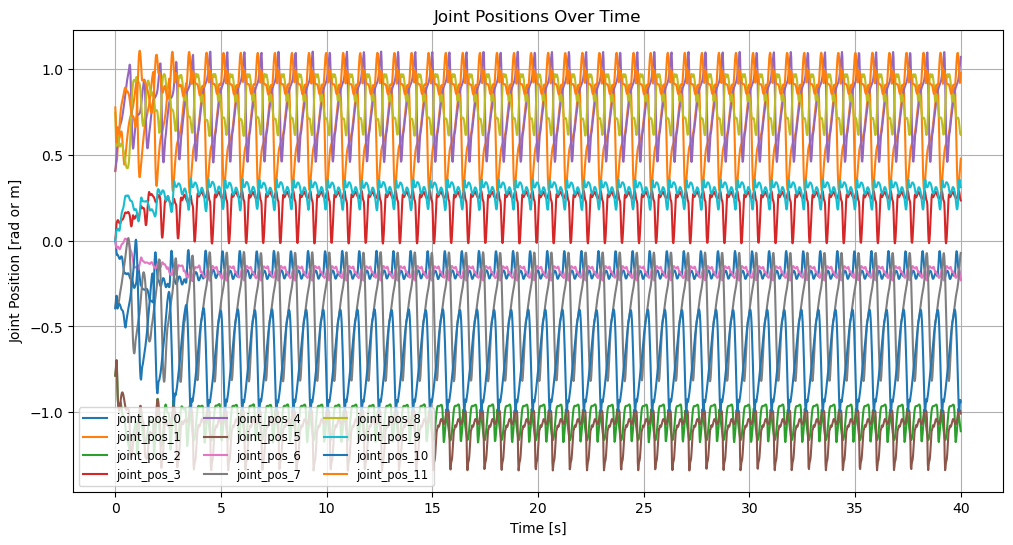

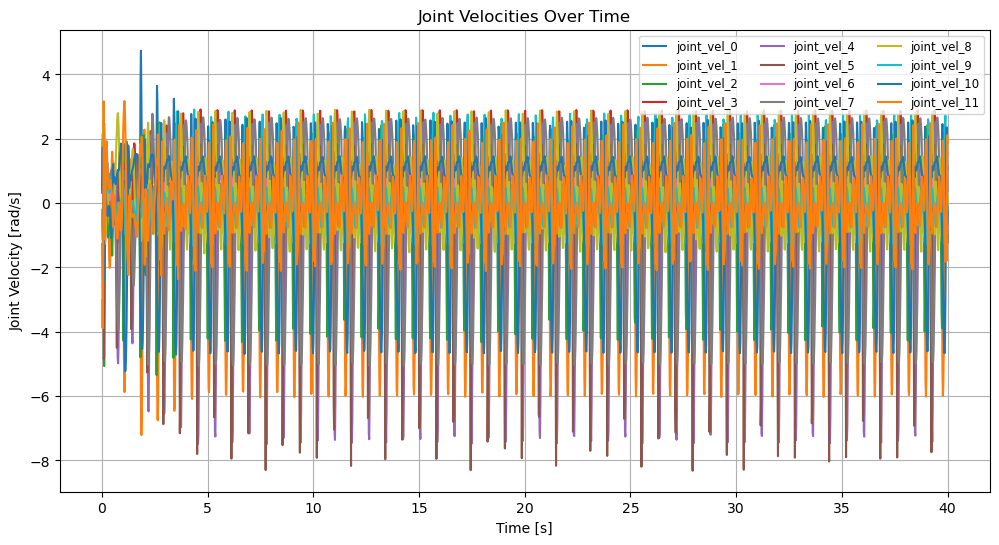

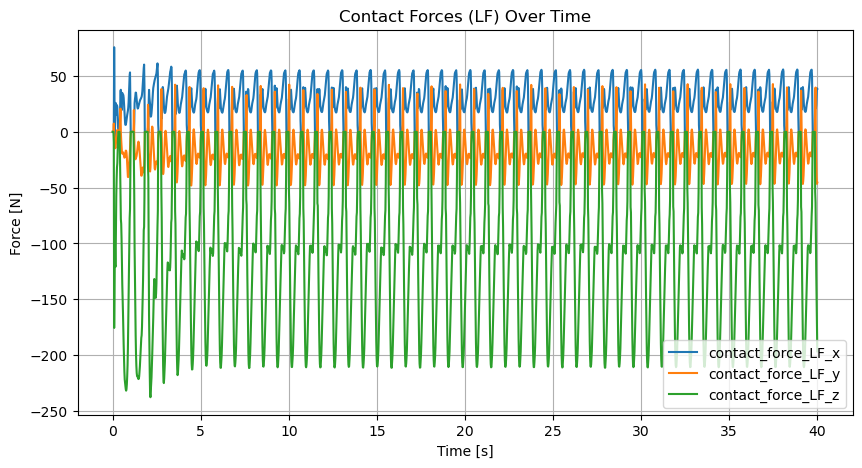

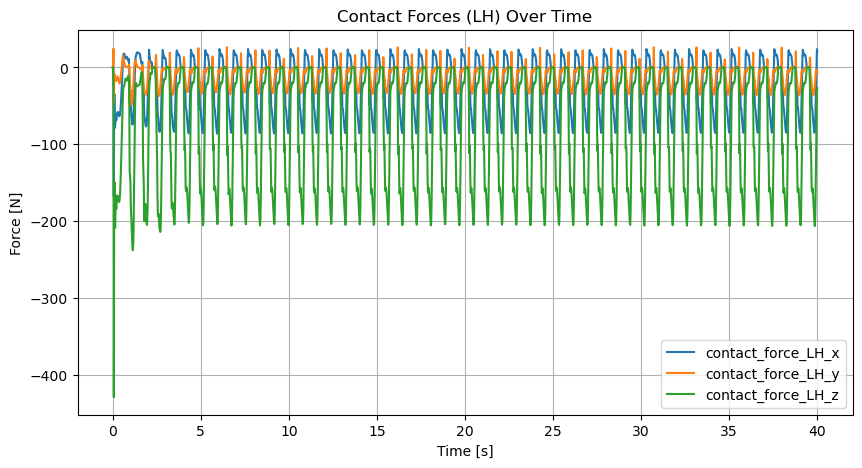

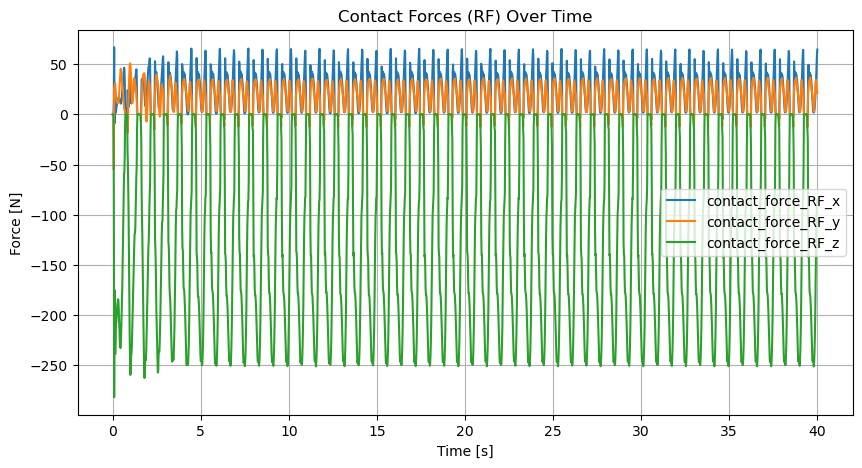

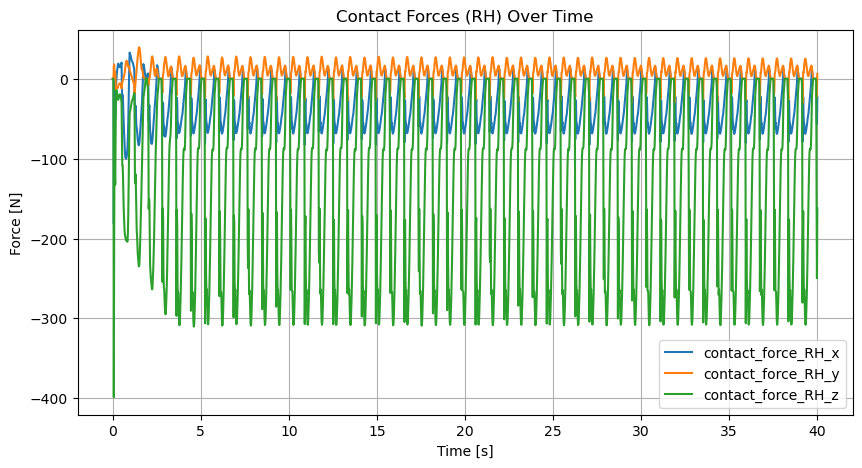

In [6]:
# Mujoco Replay

import pandas as pd
import matplotlib.pyplot as plt

# ---- CONFIG ----
CSV_FILE = "force_mujoco_single_robot_log.csv"  # Change to your actual file path
SHOW_FIG = True              # Set False if you just want to save the figures
SAVE_FIG = False              # Saves all plots as PNGs
# ----------------

# Read CSV
df = pd.read_csv(CSV_FILE)
df = df[df['time'].between(0, 40)]  # Filter to match IsaacLab replay data since we have more than 40 seconds of data

# --- BASE POSITION ---
plt.figure(figsize=(10, 5))
plt.plot(df['time'], df['base_pos_x'], label='base_pos_x')
plt.plot(df['time'], df['base_pos_y'], label='base_pos_y')
plt.plot(df['time'], df['base_pos_z'], label='base_pos_z')
plt.title("Base Position Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.legend()
plt.grid(True)
if SAVE_FIG: plt.savefig("base_position.png", dpi=200, bbox_inches='tight')

# --- BASE ORIENTATION (QUATERNION) ---
plt.figure(figsize=(10, 5))
plt.plot(df['time'], df['base_quat_w'], label='quat_w')
plt.plot(df['time'], df['base_quat_x'], label='quat_x')
plt.plot(df['time'], df['base_quat_y'], label='quat_y')
plt.plot(df['time'], df['base_quat_z'], label='quat_z')
plt.title("Base Orientation (Quaternion) Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Quaternion Value")
plt.legend()
plt.grid(True)
if SAVE_FIG: plt.savefig("base_orientation.png", dpi=200, bbox_inches='tight')

# --- JOINT POSITIONS ---
joint_pos_cols = [col for col in df.columns if col.startswith('joint_pos_')]
plt.figure(figsize=(12, 6))
for col in joint_pos_cols:
    plt.plot(df['time'], df[col], label=col)
plt.title("Joint Positions Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Joint Position [rad or m]")
plt.legend(ncol=3, fontsize='small')
plt.grid(True)
if SAVE_FIG: plt.savefig("joint_positions.png", dpi=200, bbox_inches='tight')

# --- JOINT VELOCITIES ---
joint_vel_cols = [col for col in df.columns if col.startswith('joint_vel_')]
plt.figure(figsize=(12, 6))
for col in joint_vel_cols:
    plt.plot(df['time'], df[col], label=col)
plt.title("Joint Velocities Over Time")
plt.xlabel("Time [s]")
plt.ylabel("Joint Velocity [rad/s]")
plt.legend(ncol=3, fontsize='small')
plt.grid(True)
if SAVE_FIG: plt.savefig("joint_velocities.png", dpi=200, bbox_inches='tight')

# --- CONTACT FORCES ---
contact_force_cols = [col for col in df.columns if col.startswith('contact_force_')]

# Group by limb (LF, RF, LH, RH)
limbs = sorted(set(col.split('_')[2] for col in contact_force_cols))  # ['LF', 'LH', 'RF', 'RH']

for limb in limbs:
    plt.figure(figsize=(10, 5))
    cols = [col for col in contact_force_cols if f'_{limb}_' in col]
    for col in cols:
        plt.plot(df['time'], df[col], label=col)
    plt.title(f"Contact Forces ({limb}) Over Time")
    plt.xlabel("Time [s]")
    plt.ylabel("Force [N]")
    plt.legend()
    plt.grid(True)
    if SAVE_FIG:
        plt.savefig(f"contact_forces_{limb}.png", dpi=200, bbox_inches='tight')


if SHOW_FIG:
    plt.show()
